In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as snssns

In [ ]:
orders= pd.read_csv("/content/orders.csv")

In [ ]:
orders_details= pd.read_csv("/content/order_details.csv")

In [ ]:
merged_order_details=pd.merge(orders, orders_details, on= 'order_id', how ='inner')

In [ ]:
merged_order_details.isna().sum()

,0
order_id,0
date,0
time,0
order_details_id,0
pizza_id,0
quantity,0


In [ ]:
pizzas= pd.read_csv("/content/pizzas.csv")

In [ ]:
pizza_types= pd.read_csv('/content/pizza_types.csv', encoding='latin1')

In [ ]:
merged_pizza_types=pd.merge(pizzas, pizza_types, on= 'pizza_type_id', how ='inner')

In [ ]:
merged_pizza_types.isna().sum()

,0
pizza_id,0
pizza_type_id,0
size,0
price,0
name,0
category,0
ingredients,0


In [ ]:
complete_merge=pd.merge(merged_order_details, merged_pizza_types, on= 'pizza_id', how ='inner')

In [ ]:
complete_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          48620 non-null  int64  
 1   date              48620 non-null  object 
 2   time              48620 non-null  object 
 3   order_details_id  48620 non-null  int64  
 4   pizza_id          48620 non-null  object 
 5   quantity          48620 non-null  int64  
 6   pizza_type_id     48620 non-null  object 
 7   size              48620 non-null  object 
 8   price             48620 non-null  float64
 9   name              48620 non-null  object 
 10  category          48620 non-null  object 
 11  ingredients       48620 non-null  object 
dtypes: float64(1), int64(3), object(8)
memory usage: 4.5+ MB


##Dataset merging into a fully merged cell

In [ ]:
total_sales=complete_merge['price'].sum()

In [ ]:
print(total_sales) # Total sales/revenue

801944.7000000001


In [ ]:
total_quantity_sold=complete_merge['quantity'].sum() #To find total quantity sold

In [ ]:
print(total_quantity_sold) # Total quantity sold

49574


In [ ]:
total_order = len(complete_merge['order_id'])

In [ ]:
print(total_order) # Total orderorder

48620


In [ ]:
pizza_types_sold=complete_merge["pizza_type_id"].nunique()

In [ ]:
print(pizza_types_sold)

32


#types of pizza

In [ ]:
Avg_price_pizza= complete_merge["price"].mean() #average pizza price

In [ ]:
print(Avg_price_pizza)

16.494132044426163


#peak hours of sales

In [ ]:
complete_merge.shape

(48620, 12)

In [ ]:
complete_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          48620 non-null  int64  
 1   date              48620 non-null  object 
 2   time              48620 non-null  object 
 3   order_details_id  48620 non-null  int64  
 4   pizza_id          48620 non-null  object 
 5   quantity          48620 non-null  int64  
 6   pizza_type_id     48620 non-null  object 
 7   size              48620 non-null  object 
 8   price             48620 non-null  float64
 9   name              48620 non-null  object 
 10  category          48620 non-null  object 
 11  ingredients       48620 non-null  object 
dtypes: float64(1), int64(3), object(8)
memory usage: 4.5+ MB


In [ ]:
complete_merge.head(48620)

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients
0,1,2015-01-01,11:38:36,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2015-01-01,11:57:40,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,2,2015-01-01,11:57:40,3,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,2,2015-01-01,11:57:40,4,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,2,2015-01-01,11:57:40,5,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."
...,...,...,...,...,...,...,...,...,...,...,...,...
48615,21348,2015-12-31,21:23:10,48616,ckn_alfredo_m,1,ckn_alfredo,M,16.75,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
48616,21348,2015-12-31,21:23:10,48617,four_cheese_l,1,four_cheese,L,17.95,The Four Cheese Pizza,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo..."
48617,21348,2015-12-31,21:23:10,48618,napolitana_s,1,napolitana,S,12.00,The Napolitana Pizza,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,..."
48618,21349,2015-12-31,22:09:54,48619,mexicana_l,1,mexicana,L,20.25,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


In [ ]:
peak_hours=complete_merge['time'].value_counts()
print(peak_hours)

time
12:32:00    26
11:59:10    24
12:26:04    23
12:52:36    23
12:53:29    23
            ..
15:25:31     1
14:03:30     1
21:40:04     1
21:06:36     1
17:36:51     1
Name: count, Length: 16382, dtype: int64


In [ ]:
complete_merge.sort_values(by="time", inplace=True, ascending=False) # descending peak hourshours

In [ ]:
complete_merge.head(5)

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients
28220,12433,2015-07-26,23:05:52,28221,veggie_veg_m,1,veggie_veg,M,16.00,The Vegetables + Vegetables Pizza,Veggie,"Mushrooms, Tomatoes, Red Peppers, Green Pepper..."
28219,12433,2015-07-26,23:05:52,28220,spinach_supr_m,1,spinach_supr,M,16.50,The Spinach Supreme Pizza,Supreme,"Spinach, Red Onions, Pepperoni, Tomatoes, Arti..."
7094,3133,2015-02-21,23:05:24,7095,mediterraneo_l,1,mediterraneo,L,20.25,The Mediterranean Pizza,Veggie,"Spinach, Artichokes, Kalamata Olives, Sun-drie..."
7096,3133,2015-02-21,23:05:24,7097,soppressata_l,1,soppressata,L,20.75,The Soppressata Pizza,Supreme,"Soppressata Salami, Fontina Cheese, Mozzarella..."
7095,3133,2015-02-21,23:05:24,7096,napolitana_l,1,napolitana,L,20.50,The Napolitana Pizza,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,..."


In [ ]:
complete_merge["date"] = pd.to_datetime(complete_merge["date"])

In [ ]:
complete_merge["day_of_week"] = complete_merge["date"].dt.day_name()

In [ ]:
sales_by_day = complete_merge.groupby("day_of_week")["price"].sum() #sales by day

In [ ]:
print(sales_by_day)

day_of_week
Friday       133773.90
Monday       105357.15
Saturday     120865.30
Sunday        97264.75
Thursday     120912.45
Tuesday      111764.70
Wednesday    112006.45
Name: price, dtype: float64


In [ ]:
sales_by_day.max() #day with Highest sales

133773.9

In [ ]:
(complete_merge.groupby("pizza_type_id")["quantity"]
    .sum()
        .sort_values(ascending=False)
            .head(5))

,quantity
pizza_type_id,
classic_dlx,2453
bbq_ckn,2432
hawaiian,2422
pepperoni,2418
thai_ckn,2371


#top5_pizza

In [ ]:
(complete_merge.groupby("pizza_type_id")["quantity"]
    .sum()
        .sort_values()
            .head(5)) #the least selling pizzaspizzas

,quantity
pizza_type_id,
brie_carre,490
mediterraneo,934
calabrese,937
spinach_supr,950
soppressata,961


In [ ]:
complete_merge["date"] = pd.to_datetime(complete_merge["date"])

In [ ]:
complete_merge["month"] =complete_merge["date"].dt.month_name() #converting data to month in words

In [ ]:
complete_merge["year_month"] = complete_merge["date"].dt.to_period('M')
monthly_sales = (
     complete_merge.groupby("year_month")["price"]
         .sum()
             .sort_index()
)

In [ ]:
sales_by_month_name = (
    complete_merge.groupby("month")["price"]
        .sum()
        .reindex([
            'January', 'February', 'March', 'April', 'May', 'June',
            'July', 'August', 'September', 'October', 'November', 'December'
        ])
)
display(sales_by_month_name)

,price
month,
January,68472.70
February,64067.40
March,69198.00
April,67286.20
May,69939.35
June,66796.30
July,71027.45
August,67068.80
September,63018.00


In [ ]:
print(sales_by_month_name) #sales by monthmonth

month
January      68472.70
February     64067.40
March        69198.00
April        67286.20
May          69939.35
June         66796.30
July         71027.45
August       67068.80
September    63018.00
October      62566.50
November     69054.00
December     63450.00
Name: price, dtype: float64


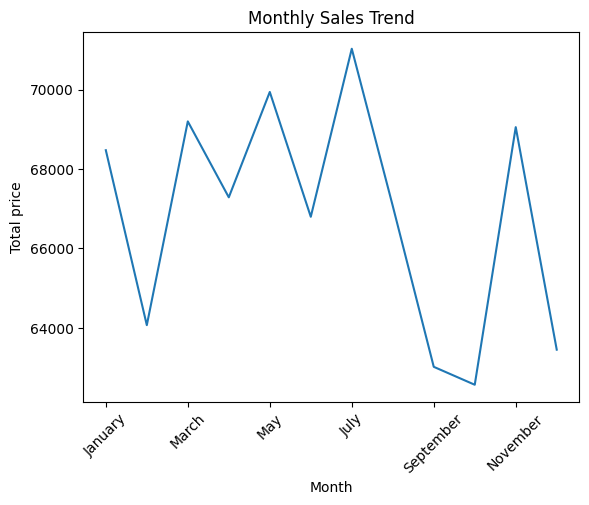

In [ ]:
#trend in monthly salesalessalesalesss
sales_by_month_name.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total price")
plt.xticks(rotation=45)
plt.show()

#there was a fall in the sales of pizza from August to October and a sharp increase in the month of November and then a fall in December.